# 03 - Training a DDM on WikiText-2

**Summary.** This notebook runs one full training loop with
`configs/ddm_base.yaml` (learned gate g(k)), plots the training/validation
curves and the learned g(k) curves, and prints the final test results.
Set `DDM_SMOKE=1` in the environment for a tiny smoke run (few steps).

In [1]:
# --- repo root bootstrap: lets the notebook run from any working directory ---
import os, sys
from pathlib import Path

def _find_root() -> Path:
    here = Path.cwd()
    for cand in [here, here.parent, here.parent.parent]:
        if (cand / "configs").is_dir() and (cand / "src" / "ddm").is_dir():
            return cand
    return here

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
SMOKE = os.environ.get("DDM_SMOKE", "0") == "1"
print("repo root:", ROOT, "| DDM_SMOKE:", SMOKE)


repo root: C:\Users\yasir\Desktop\ammar | DDM_SMOKE: True


In [2]:
from ddm.config import DDMConfig
from ddm.train import run_training, format_results_table
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [3]:
config = DDMConfig.from_yaml("configs/ddm_base.yaml")
print(config)

DDMConfig(model_type='ddm', vocab_size=50257, d_model=128, n_layers=2, n_heads=4, max_seq_len=128, n_context=3, learn_g=True, dropout=0.0, batch_size=32, lr=0.0003, epochs=5, seeds=[0, 1], dataset_name='wikitext', dataset_config='wikitext-2-raw-v1', cache_dir='hf_cache', shuffle=False, eval_buckets=[(0, 10), (10, 50), (50, 200)], log_every=50, save_dir='checkpoints', max_steps=None, max_blocks=None, device='')


In [4]:
if SMOKE:
    # quick CI/smoke run: tiny data, one epoch, few steps
    config.max_steps = 3
    config.max_blocks = 64
    config.epochs = 1
    config.seeds = config.seeds[:1]
    print("[smoke] reduced: max_steps=3, max_blocks=64, epochs=1")


[smoke] reduced: max_steps=3, max_blocks=64, epochs=1


In [5]:
results = run_training(config)

[train] device: cuda
[data] loading wikitext/wikitext-2-raw-v1 (cache: hf_cache)...


[data] script-based loading failed (HfUriError: Invalid HF URI 'hf://datasets/wikitext@b08601e04326c79dfdd32d625aee71d232d685c3/.huggingface.yaml'. Repository id must be 'namespace/name', got 'wikitext'.); switching to local parquet fallback...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2391884 > 1024). Running this sequence through the model will result in indexing errors


[data] blocks -> train: (64, 128), val: (64, 128), test: (64, 128)
[train] vocab_size: 50257

=== seed 0 ===


[train] ddm parameters: 13,312,947


--- epoch 1/1 ---


[train] epoch 1: loss 10.9994, val PPL 56734.66


[train] test PPL: 57969.15 (2.7s)


### Training curves (per seed)

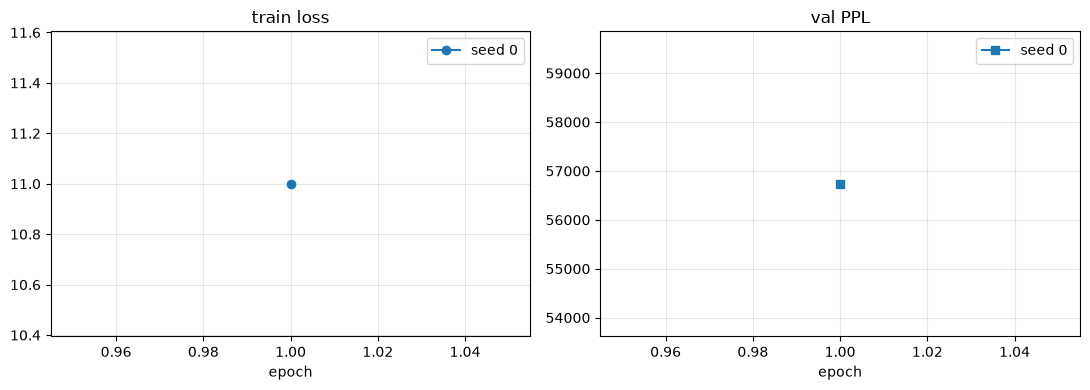

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for entry in results["per_seed"]:
    ep = np.arange(1, len(entry["train_loss"]) + 1)
    axes[0].plot(ep, entry["train_loss"], marker="o", label=f"seed {entry['seed']}")
    axes[1].plot(ep, entry["val_ppl"], marker="s", label=f"seed {entry['seed']}")
axes[0].set_title("train loss"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.3)
axes[1].set_title("val PPL"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.3)
for ax in axes:
    ax.legend()
plt.tight_layout(); plt.show()

### Learned distance gate g(k) after training

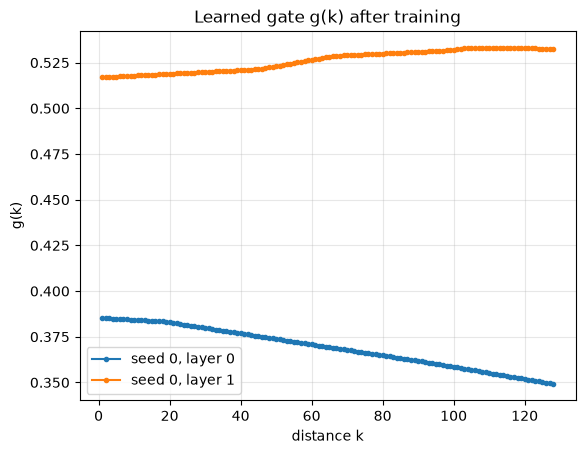

In [7]:
for entry in results["per_seed"]:
    if entry["g_curve"] is not None:
        data = np.load(entry["g_curve"].replace(".png", ".npz"))
        for layer in range(data["g"].shape[0]):
            plt.plot(data["k"], data["g"][layer], marker="o", ms=3,
                     label=f"seed {entry['seed']}, layer {layer}")
plt.xlabel("distance k"); plt.ylabel("g(k)")
plt.title("Learned gate g(k) after training"); plt.grid(alpha=0.3); plt.legend()
plt.show()

In [8]:
print(format_results_table(results))

| Seed | Test PPL | PPL(0-10) | PPL(10-50) | PPL(50-200) | Time (s) |
|---|---|---|---|---|---|---|
| 0 | 57969.15 | 57609.91 | 58446.17 | 57769.51 | 2.7 |
| mean | 57969.15 ± 0.00 | 57609.91 | 58446.17 | 57769.51 | 2.7 |



### How to run the full experiment```bashddm-train --config configs/ddm_base.yaml```The CLI writes the checkpoint, the g(k) curves (`.png`/`.npz`) and the losscurves into `checkpoints/`, and writes the results table to`checkpoints/results.md`.